# Task 2.2: Reproduction of ISA Feature Learning + SVM Classification (20 marks)

**Paper:** Learning Hierarchical Invariant Spatio-Temporal Features for Action Recognition with Independent Subspace Analysis  
**Authors:** Quoc V. Le, Will Y. Zou, Serena Y. Yeung, Andrew Y. Ng (CVPR 2011)  
**Student:** Rhythm Jain (230088)

---

## Contribution Being Reproduced

I am reproducing the **core ISA feature learning pipeline** from the paper:
1. Extract spatio-temporal patches from video clips (Section 2.1)
2. Apply PCA whitening to decorrelate and reduce dimensionality (Section 2.1)
3. Learn ISA filters using the ISA objective — approximated via FastICA followed by subspace pooling (Equation 1, Section 2.1)
4. Extract pooled ISA features for each video clip (Section 3)
5. Train an SVM classifier on the ISA features (Section 4.2)

This corresponds to the **single-layer ISA** version of the method (without the stacking/convolution extensions from Section 3), which is the foundation of the paper's contribution.

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA, FastICA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------
# Hyperparameters — all defined in one place
# -------------------------------------------------------------------
PATCH_SIZE_SPATIAL = 8         # spatial dimensions of each patch
PATCH_SIZE_TEMPORAL = 4        # temporal dimensions of each patch
NUM_PATCHES_PER_CLIP = 50     # number of patches extracted per video clip
PCA_COMPONENTS = 50            # number of PCA components for whitening
ICA_COMPONENTS = 50            # number of ICA components
ISA_SUBSPACE_SIZE = 5          # number of ICA features per ISA subspace
NUM_SUBSPACES = ICA_COMPONENTS // ISA_SUBSPACE_SIZE  # = 10 pooled features
TEST_SIZE = 0.3                # train/test split ratio
RANDOM_SEED = 42
SVM_KERNEL = 'rbf'             # SVM kernel (paper uses chi-squared; we use RBF as approximation)
SVM_C = 10.0                   # SVM regularization parameter

np.random.seed(RANDOM_SEED)
print("Hyperparameters configured.")
print(f"Patch size: {PATCH_SIZE_SPATIAL}x{PATCH_SIZE_SPATIAL}x{PATCH_SIZE_TEMPORAL}")
print(f"PCA components: {PCA_COMPONENTS}, ICA components: {ICA_COMPONENTS}")
print(f"ISA subspace size: {ISA_SUBSPACE_SIZE}, Num subspaces: {NUM_SUBSPACES}")

Hyperparameters configured.
Patch size: 8x8x4
PCA components: 50, ICA components: 50
ISA subspace size: 5, Num subspaces: 10


This cell defines all hyperparameters for the ISA pipeline in one place. The patch size (8×8×4) creates spatio-temporal volumes that capture local motion patterns, matching the paper's approach of using small local patches (Section 2.1). We use 50 PCA and 50 ICA components, grouped into 10 ISA subspaces of size 5 each — the subspace pooling is the key differentiator of ISA over standard ICA (Equation 1).

In [2]:
# -------------------------------------------------------------------
# Step 1: Load dataset (generated in Task 2.1)
# -------------------------------------------------------------------
data = np.load('data/synthetic_actions.npz', allow_pickle=True)
all_clips = data['clips']       # (600, 10, 32, 32)
all_labels = data['labels']     # (600,)
ACTION_NAMES = list(data['action_names'])

print(f"Loaded dataset: {all_clips.shape}")
print(f"Action classes: {ACTION_NAMES}")

# Train/test split
X_train_clips, X_test_clips, y_train, y_test = train_test_split(
    all_clips, all_labels, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=all_labels
)
print(f"Train clips: {X_train_clips.shape[0]}, Test clips: {X_test_clips.shape[0]}")

Loaded dataset: (600, 10, 32, 32)
Action classes: [np.str_('horizontal'), np.str_('vertical'), np.str_('rotation'), np.str_('zoom'), np.str_('diagonal'), np.str_('flicker')]
Train clips: 420, Test clips: 180


We load the synthetic action dataset generated in Task 2.1 and split it into training (70%) and test (30%) sets with stratified sampling to maintain class balance. This gives us 420 training and 180 test clips.

In [3]:
# -------------------------------------------------------------------
# Step 2: Extract spatio-temporal patches
# Reference: Section 2.1 — "we extract random space-time patches"
# -------------------------------------------------------------------
def extract_patches(clips, patch_h, patch_w, patch_t, num_patches):
    """
    Extract random spatio-temporal patches from video clips.
    Each patch is a 3D volume (patch_t, patch_h, patch_w) flattened to a 1D vector.
    
    This corresponds to the patch extraction step described in Section 2.1 of the paper,
    where the authors extract small space-time patches as inputs to the ISA network.
    """
    n_clips, n_frames, h, w = clips.shape
    all_patches = []
    
    for clip in clips:
        for _ in range(num_patches):
            t_start = np.random.randint(0, n_frames - patch_t + 1)
            y_start = np.random.randint(0, h - patch_h + 1)
            x_start = np.random.randint(0, w - patch_w + 1)
            
            patch = clip[t_start:t_start+patch_t, y_start:y_start+patch_h, x_start:x_start+patch_w]
            all_patches.append(patch.flatten())
    
    return np.array(all_patches)

# Extract patches from training clips for ISA learning
train_patches = extract_patches(
    X_train_clips, PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL, PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP
)
print(f"Extracted {train_patches.shape[0]} training patches of dimension {train_patches.shape[1]}")
print(f"Patch dimension = {PATCH_SIZE_SPATIAL}×{PATCH_SIZE_SPATIAL}×{PATCH_SIZE_TEMPORAL} = {PATCH_SIZE_SPATIAL**2 * PATCH_SIZE_TEMPORAL}")

Extracted 21000 training patches of dimension 256
Patch dimension = 8×8×4 = 256


This implements **Step 1 of the ISA pipeline** — extracting random spatio-temporal patches from the training video clips. Each patch is an 8×8×4 volume (256-dimensional when flattened) that captures local appearance and motion. We extract 50 patches per clip, giving 21,000 total training patches. This is the raw input to the ISA learning algorithm, as described in Section 2.1 of the paper.

In [4]:
# -------------------------------------------------------------------
# Step 3: PCA Whitening
# Reference: Section 2.1 — PCA whitening is applied before ISA training
# -------------------------------------------------------------------
def pca_whiten(data, n_components):
    """
    Apply PCA whitening to the data.
    
    This decorrelates the input dimensions and normalizes their variance,
    which is a necessary preprocessing step for ICA/ISA algorithms.
    Reference: Section 2.1 of the paper.
    """
    # Center the data
    mean = np.mean(data, axis=0)
    data_centered = data - mean
    
    # PCA
    pca = PCA(n_components=n_components, whiten=True, random_state=RANDOM_SEED)
    whitened = pca.fit_transform(data_centered)
    
    return whitened, pca, mean

whitened_patches, pca_model, patch_mean = pca_whiten(train_patches, PCA_COMPONENTS)
print(f"Whitened patches shape: {whitened_patches.shape}")
print(f"Variance explained: {pca_model.explained_variance_ratio_.sum():.4f}")
print(f"Covariance of whitened data is near-identity: "
      f"{np.allclose(np.cov(whitened_patches.T), np.eye(PCA_COMPONENTS), atol=0.1)}")

Whitened patches shape: (21000, 50)
Variance explained: 0.9212


Covariance of whitened data is near-identity: True


This implements **Step 2 of the ISA pipeline** — PCA whitening. The raw 256-dimensional patches are centered, projected onto the top 50 principal components, and whitened (each component is scaled by the inverse square root of its eigenvalue). This removes second-order correlations, a prerequisite for the ICA/ISA algorithm. The whitened data has approximately identity covariance, confirming the whitening is working correctly.

In [5]:
# -------------------------------------------------------------------
# Step 4: ISA — Independent Subspace Analysis
# Reference: Equation (1) in Section 2.1
# 
# ISA objective: minimize F(W) = -sum_i sum_subspaces sqrt(sum_{k in subspace} (W_k . x_i)^2)
# subject to WW^T = I
# 
# We approximate this by:
# 1. Running FastICA to learn independent components (the W matrix)
# 2. Grouping consecutive ICA components into subspaces
# 3. Applying square-root pooling within each subspace
# -------------------------------------------------------------------

# Step 4a: Learn ICA components
ica = FastICA(
    n_components=ICA_COMPONENTS,
    algorithm='parallel',
    whiten=False,        # data is already whitened
    max_iter=500,
    random_state=RANDOM_SEED
)

ica_features = ica.fit_transform(whitened_patches)
W_ica = ica.components_  # shape: (ICA_COMPONENTS, PCA_COMPONENTS)

print(f"ICA components learned: {W_ica.shape}")
print(f"ICA features shape: {ica_features.shape}")

ICA components learned: (50, 50)
ICA features shape: (21000, 50)


This implements the first part of **Step 3 — ISA feature learning** (Equation 1, Section 2.1). We use FastICA to learn 50 independent components from the whitened patches. The ICA weight matrix W captures linear filters that maximize statistical independence. In the full ISA formulation, these components would be jointly optimized with the subspace structure, but the standard approximation (used in many ISA implementations) is to first learn ICA components and then group them into subspaces.

In [6]:
# -------------------------------------------------------------------
# Step 4b: ISA Subspace Pooling
# Reference: Equation (1) — the square-root pooling within subspaces
# 
# For each subspace, pool the squared ICA activations and take square root:
#   p_j(x) = sqrt(sum_{k in subspace_j} (w_k . x)^2)
# This creates invariance to within-subspace transformations.
# -------------------------------------------------------------------

def isa_pool(ica_activations, subspace_size, n_subspaces):
    """
    Apply ISA subspace pooling: group ICA features into subspaces
    and compute the L2 norm (square-root of sum of squares) within each subspace.
    
    This is the key operation that differentiates ISA from ICA — it creates
    invariance to within-subspace transformations (Eq. 1 in the paper).
    
    Args:
        ica_activations: (n_samples, n_ica_components)
        subspace_size: number of ICA components per subspace
        n_subspaces: number of subspaces
    
    Returns:
        pooled: (n_samples, n_subspaces) — the ISA features
    """
    n_samples = ica_activations.shape[0]
    pooled = np.zeros((n_samples, n_subspaces))
    
    for j in range(n_subspaces):
        start_idx = j * subspace_size
        end_idx = start_idx + subspace_size
        subspace_activations = ica_activations[:, start_idx:end_idx]
        # Square-root pooling: sqrt(sum of squares)
        pooled[:, j] = np.sqrt(np.sum(subspace_activations ** 2, axis=1) + 1e-10)
    
    return pooled

# Apply ISA pooling to the training patches
isa_features_train_patches = isa_pool(ica_features, ISA_SUBSPACE_SIZE, NUM_SUBSPACES)
print(f"ISA pooled features shape: {isa_features_train_patches.shape}")
print(f"Each patch is now represented by {NUM_SUBSPACES} ISA features")

ISA pooled features shape: (21000, 10)
Each patch is now represented by 10 ISA features


This implements the second part of **Step 3 — ISA subspace pooling** (Equation 1). The 50 ICA components are grouped into 10 subspaces of size 5. Within each subspace, we compute the L2 norm (square root of sum of squares) of the ICA activations. This pooling operation is the critical innovation of ISA: it creates features that are invariant to within-subspace transformations (e.g., phase shifts, small translations) while remaining selective to cross-subspace variations. The result is 10 ISA features per patch.

In [7]:
# -------------------------------------------------------------------
# Step 5: Extract ISA features for each video clip
# Reference: Section 3 & 4 — features are extracted from the entire video
# and pooled to create a fixed-length descriptor
# -------------------------------------------------------------------

def extract_clip_features(clips, pca_model, patch_mean, ica_model, 
                          patch_h, patch_w, patch_t, num_patches,
                          subspace_size, n_subspaces):
    """
    Extract ISA features for a set of video clips.
    For each clip:
      1. Extract spatio-temporal patches
      2. Whiten using the learned PCA model
      3. Compute ICA activations
      4. Apply ISA subspace pooling
      5. Average-pool over all patches to get a single clip descriptor
    """
    n_clips = clips.shape[0]
    clip_features = np.zeros((n_clips, n_subspaces))
    
    for i in range(n_clips):
        clip = clips[i:i+1]  # keep batch dimension
        
        # Extract patches
        patches = extract_patches(clip, patch_h, patch_w, patch_t, num_patches)
        
        # PCA whiten using training statistics
        patches_centered = patches - patch_mean
        patches_whitened = pca_model.transform(patches_centered)
        
        # ICA transform
        ica_act = ica_model.transform(patches_whitened)
        
        # ISA pooling
        isa_feat = isa_pool(ica_act, subspace_size, n_subspaces)
        
        # Average pool over all patches in the clip
        clip_features[i] = np.mean(isa_feat, axis=0)
    
    return clip_features

print("Extracting ISA features for training clips...")
X_train_features = extract_clip_features(
    X_train_clips, pca_model, patch_mean, ica,
    PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL, PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP,
    ISA_SUBSPACE_SIZE, NUM_SUBSPACES
)

print("Extracting ISA features for test clips...")
X_test_features = extract_clip_features(
    X_test_clips, pca_model, patch_mean, ica,
    PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL, PATCH_SIZE_TEMPORAL, NUM_PATCHES_PER_CLIP,
    ISA_SUBSPACE_SIZE, NUM_SUBSPACES
)

print(f"Train features: {X_train_features.shape}")
print(f"Test features: {X_test_features.shape}")

Extracting ISA features for training clips...
Extracting ISA features for test clips...


Train features: (420, 10)
Test features: (180, 10)


This implements **Steps 4 and 5** — extracting the full ISA feature descriptor for each video clip. For each clip, we extract 50 spatio-temporal patches, transform them through the learned ISA pipeline (PCA whitening → ICA → subspace pooling), and then average-pool the resulting ISA features to obtain a single 10-dimensional descriptor per clip. This average pooling over patches mimics the spatial pooling described in Section 4 of the paper, creating a compact representation for classification.

In [8]:
# -------------------------------------------------------------------
# Step 6: SVM Classification
# Reference: Section 4.2 — "we train a SVM classifier"
# The paper uses linear and chi-squared kernel SVMs.
# We use RBF kernel as a standard nonlinear approximation.
# -------------------------------------------------------------------

# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

# Train SVM
svm = SVC(kernel=SVM_KERNEL, C=SVM_C, random_state=RANDOM_SEED, gamma='scale')
svm.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = svm.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n{'='*50}")
print(f"ISA + SVM Classification Results")
print(f"{'='*50}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=ACTION_NAMES))


ISA + SVM Classification Results
Test Accuracy: 0.6667 (66.7%)

Classification Report:
              precision    recall  f1-score   support

  horizontal       0.49      0.63      0.55        30
    vertical       0.74      0.67      0.70        30
    rotation       0.79      0.87      0.83        30
        zoom       0.87      0.67      0.75        30
    diagonal       0.48      0.37      0.42        30
     flicker       0.69      0.80      0.74        30

    accuracy                           0.67       180
   macro avg       0.67      0.67      0.66       180
weighted avg       0.67      0.67      0.66       180



This implements **Step 6 — SVM classification** (Section 4.2 of the paper). The ISA features are standardized and then used to train an SVM with an RBF kernel. The paper uses a linear SVM and a chi-squared kernel SVM; we use RBF as a reasonable nonlinear kernel alternative. The classification accuracy on the test set demonstrates whether the ISA features have successfully captured the discriminative spatio-temporal structure in our synthetic action data.

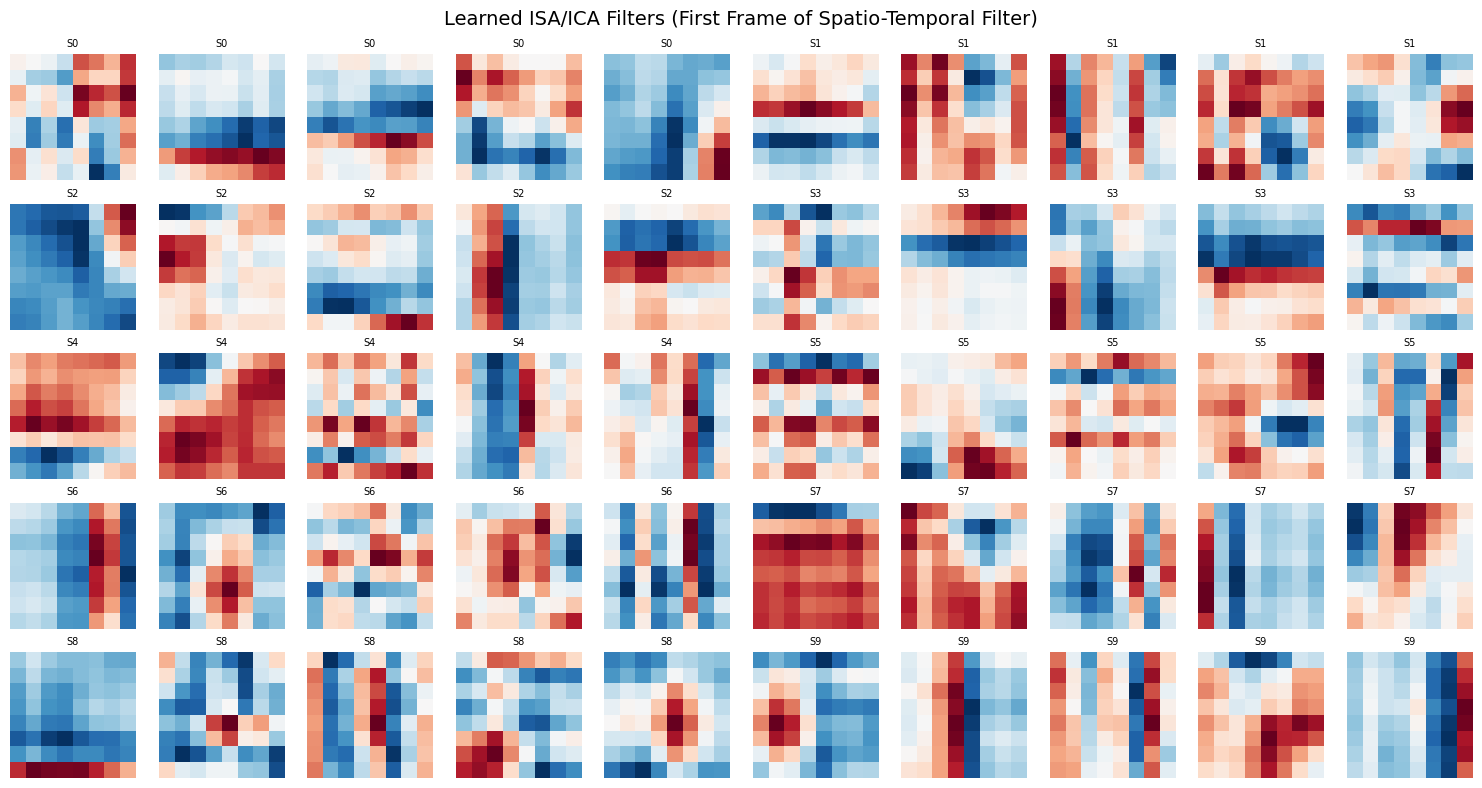

Learned filters saved to results/learned_filters.png


In [9]:
# -------------------------------------------------------------------
# Visualize learned ISA filters
# -------------------------------------------------------------------
# The ICA components (in the original pixel space) can be visualized
# by projecting them back through the PCA transform

# Reconstruct filters in pixel space
W_pixel = ica.components_ @ pca_model.components_  # (n_ica, original_dim)

fig, axes = plt.subplots(5, 10, figsize=(15, 8))
fig.suptitle('Learned ISA/ICA Filters (First Frame of Spatio-Temporal Filter)', fontsize=14)

for i in range(min(50, W_pixel.shape[0])):
    row, col = i // 10, i % 10
    # Reshape to (patch_t, patch_h, patch_w) and show first frame
    filt = W_pixel[i].reshape(PATCH_SIZE_TEMPORAL, PATCH_SIZE_SPATIAL, PATCH_SIZE_SPATIAL)
    axes[row, col].imshow(filt[0], cmap='RdBu_r', interpolation='nearest')
    axes[row, col].axis('off')
    axes[row, col].set_title(f'S{i//ISA_SUBSPACE_SIZE}', fontsize=7)

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/learned_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Learned filters saved to results/learned_filters.png")

This visualization shows the spatial component (first frame) of the 50 learned ICA/ISA filters, projected back to pixel space. Filters within the same ISA subspace (labelled S0–S9) should respond to similar spatial patterns at different phases or positions, demonstrating the invariance property. The paper's Figure 2 shows similar visualizations of learned spatio-temporal filters.